## **Análisis de Señales EEG para la Identificación de Patrones en Tareas de Imaginación Motora**

Pamela Huacca Arce | Paula Andrea Cataño Cano

### **1. Introducción**

El desarrollo de las Interfaces Cerebro-Computador (BCI) representa un desafío ambicioso en la ingeniería contemporánea, al establecer un canal directo de comunicación entre el cerebro y dispositivos externos sin depender de las vías neuromusculares tradicionales. El presente trabajo se enmarca en la evaluación de la factibilidad de sistemas BCI no invasivos, utilizando señales de electroencefalografía (EEG) para diferenciar estados de reposo, movimiento real y, fundamentalmente, imaginación motora (Motor Imagery).  

A través del uso de herramientas integradas en Python, este proyecto busca implementar un flujo de procesamiento que permita la manipulación de bioseñales, la aplicación de algoritmos de procesamiento y el análisis de la densidad espectral de potencia (PSD) para realizar inferencias estadísticas sobre los ritmos cerebrales asociados al control motor.


### **2. Marco Teórico y Estado del Arte**

**2.1 Evolución y Perspectivas de las Interfaces Cerebro-Computador (BCI)**

La interacción entre señales eléctricas y funciones biológicas ha recorrido un camino extenso desde los registros de Luigi Galvani en 1771 y Richard Caton en 1875, quienes sentaron las bases de la bioelectricidad. Sin embargo, el hito fundamental para este proyecto ocurre en 1924, cuando Hans Berger registra el primer EEG humano, identificando los ritmos alfa y beta. Este descubrimiento fue perfeccionado por Herbert Jasper, quien estandarizó la colocación de electrodos para optimizar el procesamiento de señales en tiempo real. Finalmente, en 1948, William Grey Walter desarrolló la Machina Speculatrix, uno de los primeros sistemas capaces de establecer una comunicación básica entre el cerebro y un dispositivo externo.  

En la actualidad, las BCI han pasado de ser experimentos de laboratorio a herramientas clínicas para la neurorrehabilitación post-ictus y el control de prótesis, así como aplicaciones en el entretenimiento mediante dispositivos portátiles y no invasivos. El futuro de esta tecnología apunta hacia sistemas de "circuito cerrado" y neuro-aumentación, integrando bioseñales con entornos de realidad virtual y aumentada.   

**2.2 Fundamentos Neurofisiológicos del Movimiento**

Para el análisis de tareas de movimiento (MM) e imaginación motora (MI), es crucial identificar la actividad en la corteza motora. Según el sistema internacional 10-20, los electrodos de mayor relevancia son **C3** (hemisferio izquierdo, asociado a la mano derecha), **C4** (hemisferio derecho, asociado a la mano izquierda) y **Cz** (línea media).  

La discriminación entre condiciones se basa en dos fenómenos espectrales:
- **Ritmo Mu (8-13 Hz):** Presenta una Desincronización Relacionada con Eventos (ERD), traduciéndose en una caída de potencia cuando el sujeto ejecuta o imagina un movimiento.   
- **Ritmo Beta (13-30 Hz):** Relacionado con la alerta motora y caracterizado por un "rebote" de potencia tras finalizar la tarea.   

Investigaciones previas indican que  es posible predecir rangos de frecuencia específicos para MI en los electrodos C3 y C4 que oscilan entre los 8 y 26 Hz, permitiendo así una diferenciación matemática del estado de reposo. Para efectos de este trabajo se analizarán también los electrodos con una cercanía a los electrodos de interés reportados en la litaratura, con el fin de terner información de la mayor parte de la cprteza mototra y extraer inofrmación significante de cada caso. (C1, C2, CP1, CP2, FC1, FC2, C4, C5).

![corteza motora](image.png)


### **3. Planteamineto de hipótesis**

**3.1 Comparación Reposo vs. Imaginería (Focalizada en ritmo Mu)**
- Hipótesis Nula ($H_0$): No existen diferencias significativas en la densidad espectral de potencia (PSD) de la banda Mu (8-13 Hz) entre el estado de reposo (CE/OE) y la tarea de imaginería motora.
- Hipótesis Alternativa ($H_1$): La potencia en la banda Mu disminuye significativamente (ERD) durante la imaginería motora en comparación con el estado de reposo.

**3.2 Comparación Imaginería vs. Movimiento Real (Similitud funcional)**
- Hipótesis Nula ($H_0$): No existen diferencias significativas en la distribución topográfica y espectral de la señal de EEG entre la ejecución del movimiento real y la imaginación del mismo.
- Hipótesis Alternativa ($H_1$): Existen diferencias significativas en la magnitud de la potencia espectral entre el movimiento real y la imaginería, aunque compartan la misma localización espacial (corteza motora).

### **4. Flujo de Procesamiento Propuesto**
Para cumplir con el pbejtivo de análisis, el flujo de procesamiento debe seguir estos pasos lógicos:


1. Carga y Limpieza: Importar los datos y aplicar filtros lineales (paso de banda, detrend) para eliminar tendencias lineales provocadas por los cambios en la impedancia, ruidos de baja frecuencia y ruido muscular.

- Se implementará un filtro pasabanda FIR  con frecuencias de corte entre 8 Hz y 30 Hz. Este rango permite aislar los ritmos Mu (8-13 Hz) y Beta (13-30 Hz), eliminando ruidos de alta frecuencia y artefactos no biológicos.

2. Segmentación (Epoching): Segmentación (Epoching): La señal continua se dividirá en épocas utilizando los marcadores de eventos del dataset. Se extraerán segmentos correspondientes a las cuatro condiciones: movimiento mano derecha/izquierda e imaginación mano derecha/izquierda, además de los periodos de reposo.

4.  Extracción de Características (PSD): Se calculará la Densidad Espectral de Potencia (PSD) mediante el método de Welch. Esta técnica permitirá promediar el periodograma para obtener una estimación robusta de la potencia en las bandas de interés, facilitando la comparación entre las condiciones de tarea y reposo.

5. Análisis de pruebas estadísticas: Se evaluará la normalidad de la distribución de la potencia mediante pruebas como Shapiro-Wilk. En caso de normalidad, se emplearán pruebas paramétricas (t-student); de lo contrario, se utilizarán pruebas no paramétricas (man- whitney) para comparar las medias de potencia entre las condiciones.

6. Representación de Resultados: Se utilizarán Boxplots (diagramas de caja) para describir la dispersión de la potencia y facilitar la identificación de diferencias estadísticas significativas entre las cuatro tareas y el reposo.



In [2]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import welch as pwelch
from scipy import stats
import pandas as pd
import scipy.io as sio
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

### **Verificación del Dataset**  

In [12]:
import glob

ruta = r'D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files'

carpetas_sujetos = glob.glob(os.path.join(ruta, "S*"))

print("REPORTE DE DATASET - EEG MOTOR MOVEMENT IMAGERY DATASET")
print(f"Total de sujetos encontrados: {len(carpetas_sujetos)-1}") # -1 para excluir el "SHA256SHUM.txt"

archivos_edf = glob.glob(os.path.join(carpetas_sujetos[0], "*.edf"))
print(f"Archivos .edf encontrados en el sujeto 1: {len(archivos_edf)}")
    

REPORTE DE DATASET - EEG MOTOR MOVEMENT IMAGERY DATASET
Total de sujetos encontrados: 109
Archivos .edf encontrados en el sujeto 1: 14


### **Carga y selección de canales- prueba SUJETO 01**

In [32]:
ruta_S1 = r"D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R04.edf" 
raw = mne.io.read_raw_edf(ruta_S1, preload=True, verbose=False)
raw.rename_channels(lambda x: x.strip('.')) # Para eliminar los puntos al final de los nombres de los canales
raw

# Yo dejaría la impresión del RAW para la ahí se muestra toa la info que tienes acá abajo

# print("-----EXPLORACIÓN DEL ARCHIVO EEG ----")
# print(f"Frecuencia de muestreo (Fs): {raw.info['sfreq']} Hz")
# print(f"Duración total del registro: {raw.times[-1]:.2f} segundos")
# print(f"Número total de canales: {len(raw.ch_names)}")
# print(f"Canales: {raw.ch_names} ...")

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

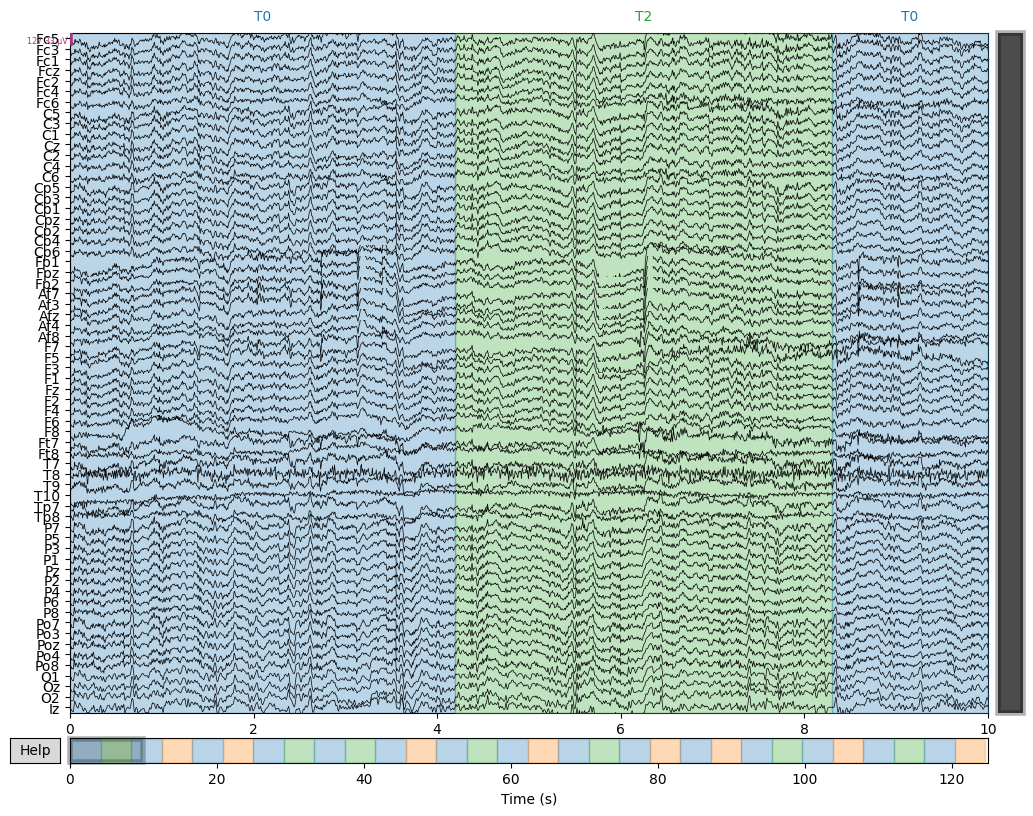

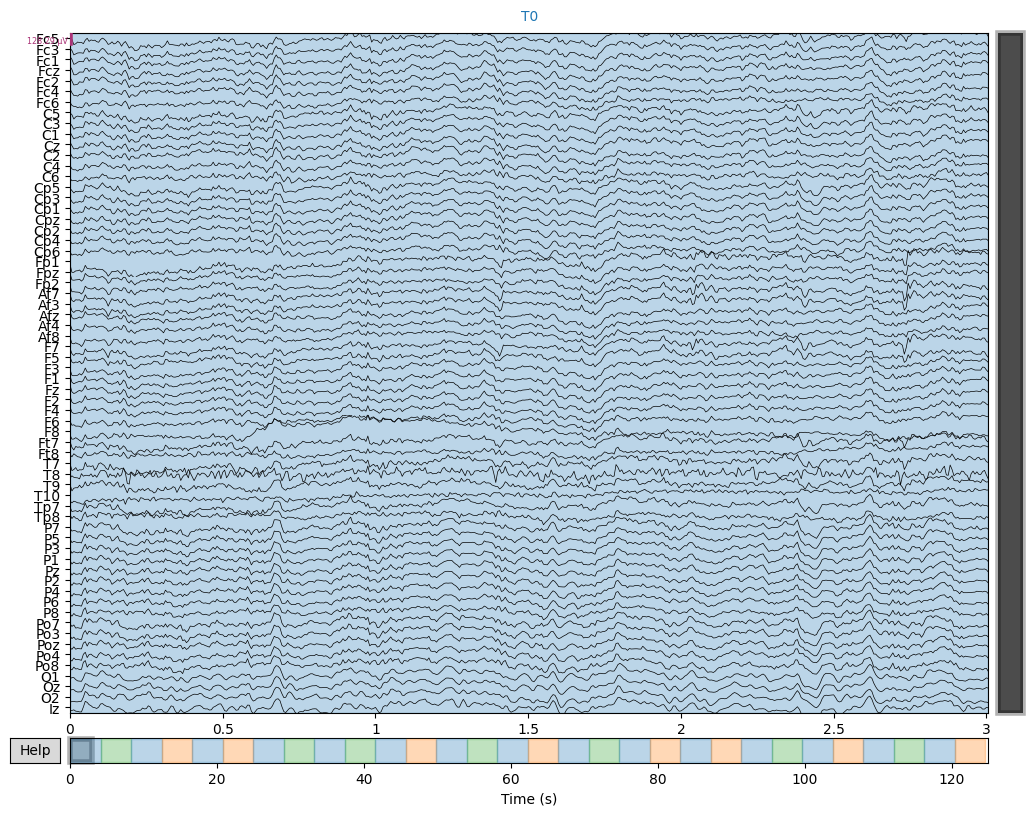

In [38]:
# INSPECCIÓN VISUAL 1: Señal cruda
raw.plot(n_channels=64, scalings='auto');
raw.plot(n_channels=64, duration=3.0, scalings='auto');

In [ ]:
# ESTO ES PARA SACAR EL TIEMPO DE REGISTRO, Y YA ESTÁ EN LA CELDA ANTERIOR

Fs = raw.info['sfreq']
datos = raw.get_data()

# TIEMPO DE LA SEÑAL
num_muestras = datos.shape[1]
Ts = 1 / Fs 
t = num_muestras * Ts 
T = np.arange(0, t, Ts) # Vector de tiempo

print(f"Tiempo total de la señal: {t} segundos")

Tiempo total de la señal: 125.0 segundos


In [30]:
#CANALES DE INTERÉS
# ==========================================
canales_interes = ['C3', 'C4', 'Cz']  # CREO QUE PODEMOS AGREGAR MÁS CANALES SI QUEREMOS,
#                                       AUNQUE ESTOS SON LOS PRINCIPALES PARA EL MOVIMIENTO MOTOR

canales_presentes = [ch for ch in raw.ch_names if any(sub in ch for sub in canales_interes)]

# Filtramos el objeto raw para quedarnos solo con esos 3
raw.pick_channels(canales_presentes)

# IMPORTANTE: Extraemos nuevamente los datos, pero ahora solo de los 3 canales aislados
datos_aislados = raw.get_data()

print("Canales aislados con éxito")
print(f"Canales finales listos para análisis: {raw.ch_names}")
print(f"Tamaño de la nueva matriz de datos: {datos_aislados.shape}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Canales aislados con éxito
Canales finales listos para análisis: ['C3', 'Cz', 'C4']
Tamaño de la nueva matriz de datos: (3, 20000)


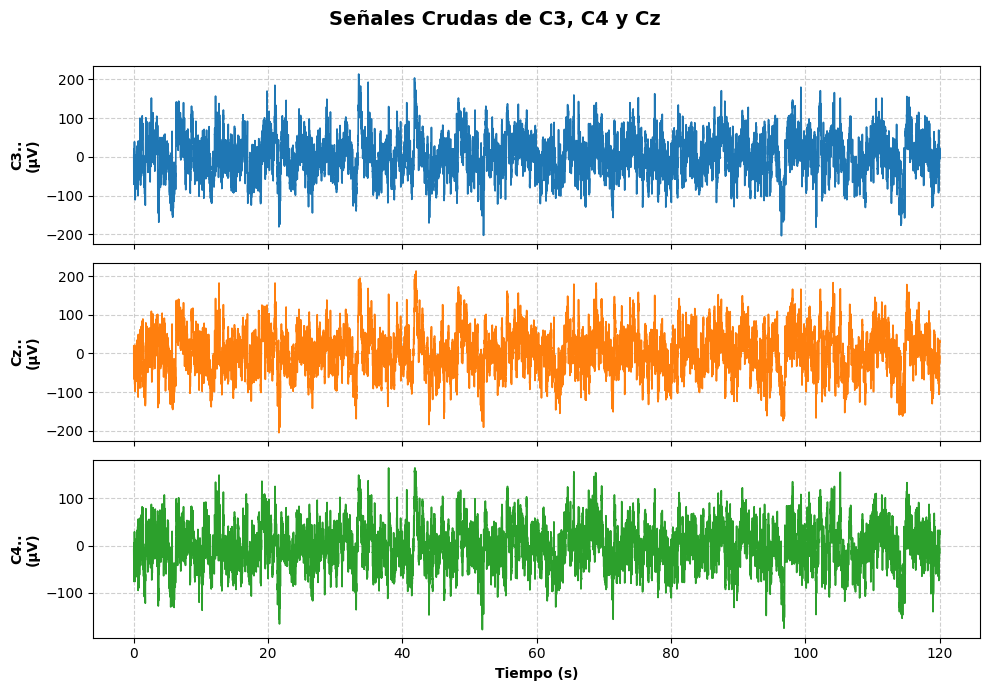

In [24]:
# GRÁFICA DE LOS CANALES de interés (C3, C4, Cz)
#  Convertimos de Voltios (V) a microVoltios (µV) 
datos_uv = datos_aislados * 1e6 

# 2.  Tiempo total de la señal 120 s 
limite = int(120 * Fs) 
T_plot = T[:limite] # Recortamos el vector de tiempo 

# 3. subplots - grafica de los tres canales 
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Señales Crudas de C3, C4 y Cz", fontsize=14, fontweight='bold')
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, canal in enumerate(raw.ch_names):
    # Usamos T_plot en el eje X, y los datos_uv en el eje Y
    axs[i].plot(T_plot, datos_uv[i, :limite], color=colores[i], linewidth=1.2)
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

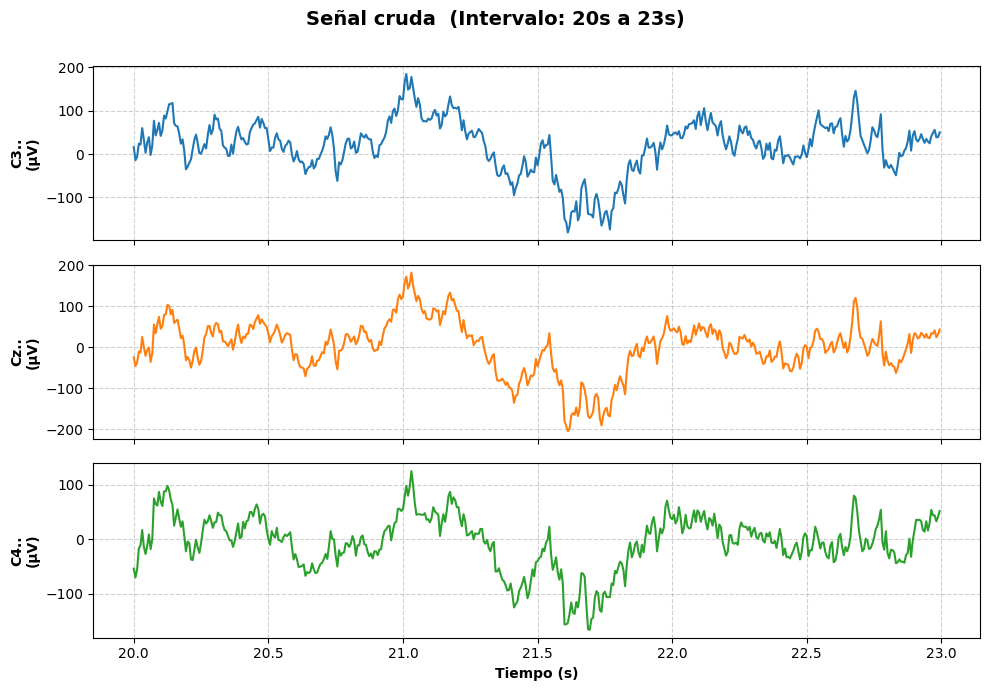

In [25]:
# GRÁFICAMOS UN INTERVALO de 3 segundos para detallar mejor las ondas
#podemos ir camnbiando para comparar diferentes segmentos
inicio_seg = 20 
fin_seg = 23     

#  muestras exactas del arreglo
idx_inicio = int(inicio_seg * Fs)
idx_fin = int(fin_seg * Fs)

# Recortamos El vector de tiempo 
T_lim = T[idx_inicio:idx_fin]

# graficamos
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f"Señal cruda  (Intervalo: {inicio_seg}s a {fin_seg}s)", fontsize=14, fontweight='bold')
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, canal in enumerate(raw.ch_names):
    # Graficamos recortando también los datos en el mismo intervalo (idx_inicio a idx_fin)
    axs[i].plot(T_lim, datos_uv[i, idx_inicio:idx_fin], color=colores[i], linewidth=1.5)
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### **Filtrado**

**Detrend**

In [34]:
from scipy.signal import detrend

print("-> Iniciando limpieza: Paso 1 Detrend ..... ")

# Copiamos la señal cruda
raw_detrend = raw.copy() 

# Identificamos los canales de EEG (C3, Cz, C4) 
# PICKS ASEGURA  que no se procese canales extra?
picks_eeg = mne.pick_types(raw_detrend.info, eeg=True, exclude='bads')

# Aplicamos detrend solo a esos canales
# Usamos channel_wise=True porque el detrend lineal se calcula por electrodo
raw_detrend.apply_function(detrend, picks=picks_eeg, channel_wise=True) #SE CAMBIÓ  EL FALSE POR TRUE 

# 4. Extraemos los datos en µV
datos_detrend = raw_detrend.get_data(picks=picks_eeg) * 1e6

print("-> Detrend completado exitosamente.")

-> Iniciando limpieza: Paso 1 Detrend ..... 
-> Detrend completado exitosamente.


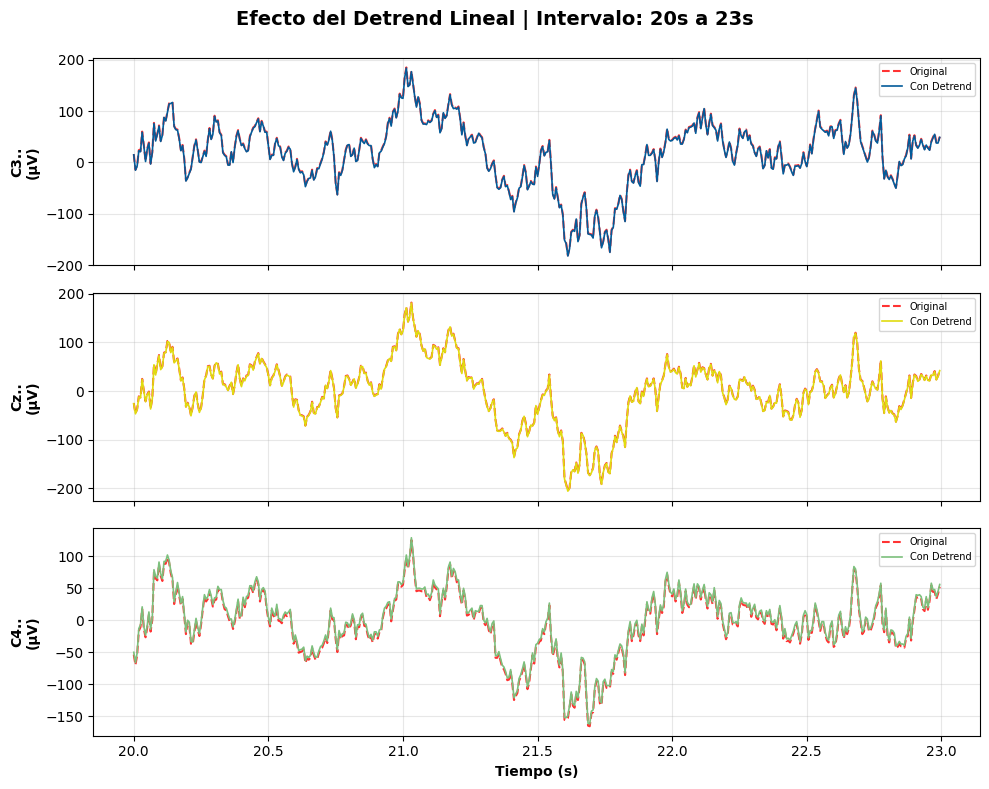

In [39]:
# GRÁFICA COMPARATIVA: SEÑAL CRUDA VS DETREND
inicio_seg = 20 
fin_seg = 23

idx_inicio = int(inicio_seg * Fs)
idx_fin = int(fin_seg * Fs)

T_zoom = T[idx_inicio:idx_fin]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f"Efecto del Detrend Lineal | Intervalo: {inicio_seg}s a {fin_seg}s", fontsize=14, fontweight='bold')

# Usamos raw_detrend.ch_names para que coincida con tus canales C3, Cz, C4
for i, canal in enumerate(raw_detrend.ch_names):
    # Señal original (Roja punteada)
    axs[i].plot(T_zoom, datos_uv[i, idx_inicio:idx_fin], color='red', linestyle='--', alpha=0.8, label='Original')
    
    # Señal con DETREND
    colores = ["#035b99", "#e0dc10", "#7dc07d"]
    axs[i].plot(T_zoom, datos_detrend[i, idx_inicio:idx_fin], color=colores[i], linewidth=1.2, label='Con Detrend')
    
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend(loc='upper right', fontsize=7)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

La señal original y la señal con detrend se ven idénticas... JUSTIFICAR 

## **Pasabandas FIR 8-30 Hz** 

In [41]:

# FILTRADO PASABANDA (8-30 Hz)
# ==========================================
print("Aplicando filtro pasabanda (8-30 Hz) a toda la grabación...")

# Copiamos la señal que ya tiene Detrend
raw_filtrado = raw_detrend.copy() 

# Identificamos solo los canales EEG (como hace el profe en sus notebooks)
picks_eeg = mne.pick_types(raw_filtrado.info, eeg=True)

# Aplicamos el filtro FIR
# Mantenemos 8-30 Hz para capturar ritmos Mu y Beta (Imaginación Motora)
raw_filtrado.filter(l_freq=8.0, h_freq=30.0, picks=picks_eeg, 
                    method='fir', fir_design='firwin', verbose=False)

# Extraemos datos limpios en µV
datos_filtrados_completos = raw_filtrado.get_data(picks=picks_eeg) * 1e6

print("-> Señal completa filtrada y extraída con éxito")
print(f"Forma de la matriz filtrada: {datos_filtrados_completos.shape}")

Aplicando filtro pasabanda (8-30 Hz) a toda la grabación...
-> Señal completa filtrada y extraída con éxito
Forma de la matriz filtrada: (3, 20000)


In [42]:
# Recortamos la señal filtrada para comparar con la cruda - intervalo 20-23 s
# Definimos el intervalo que queremos visualizar- el mismo de la señal cruda para comparar
inicio_seg = 20  
fin_seg = 23     

# Convertimos esos segundos a índices
idx_inicio = int(inicio_seg * Fs)
idx_fin = int(fin_seg * Fs)

# Recortamos el vector de tiempo
T_lim = T[idx_inicio:idx_fin]

# Recortamos la matriz de datos QUE YA ESTÁ FILTRADA
# Tomamos todas las filas (:), pero solo las columnas desde idx_inicio hasta idx_fin
datos_recortados = datos_filtrados_completos[:, idx_inicio:idx_fin] 

print(f"-> Fragmento del segundo {inicio_seg} al {fin_seg} recortado con éxito.")

-> Fragmento del segundo 20 al 23 recortado con éxito.


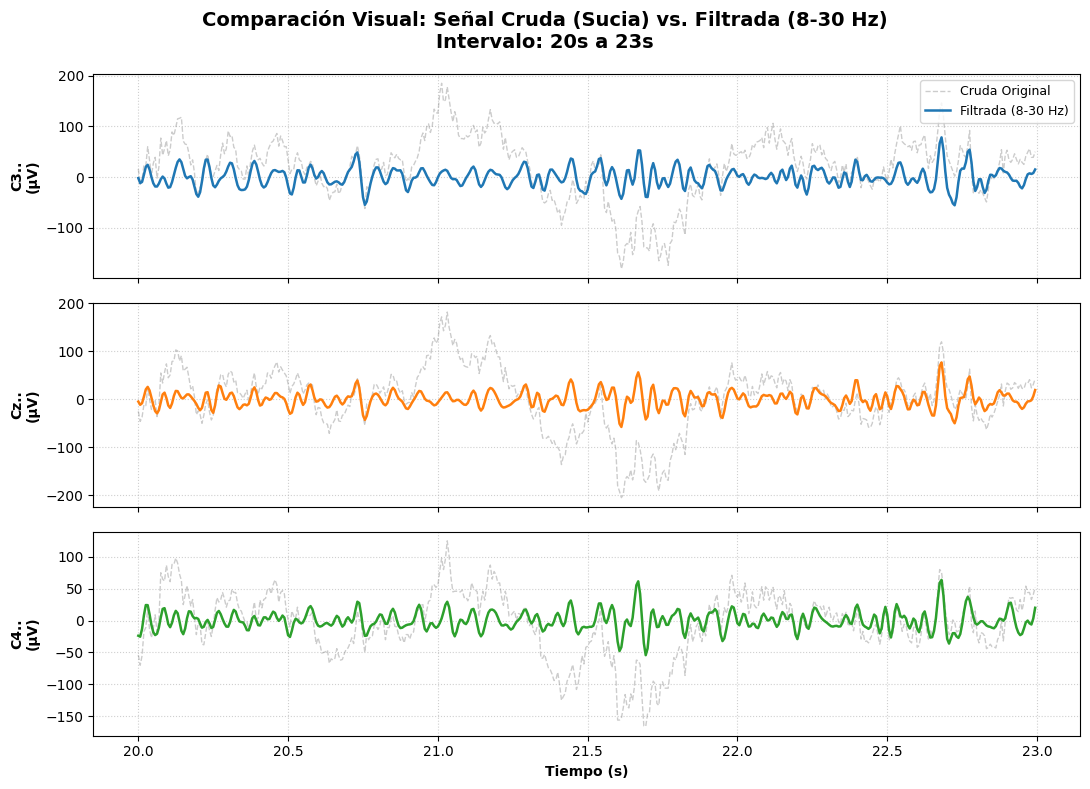

In [45]:
# GRÁFICA COMPARATIVA SUPERPUESTA
# Creamos la figura y los subplots
fig, axs = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# Títtle 
fig.suptitle(f"Comparación Visual: Señal Cruda (Sucia) vs. Filtrada (8-30 Hz)\nIntervalo: {inicio_seg}s a {fin_seg}s", 
             fontsize=14, fontweight='bold')

colores_filtrada = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Iteramos por cada uno de los 3 canales
for i, canal in enumerate(raw_filtrado.ch_names):
    # --- PASO 1: Graficar la señal CRUDA (Sucia) de fondo ---
    # Usamos color gris ('gray'), línea punteada ('--') y transparencia (alpha=0.4) 
    axs[i].plot(T_lim, datos_uv[i, idx_inicio:idx_fin], 
                color='gray', linestyle='--', alpha=0.4, linewidth=1, label='Cruda Original')
    
    # --- PASO 2: Graficar la señal FILTRADA (Limpia) encima ---
    # Usamos la variable 'datos_recortados' 
    axs[i].plot(T_lim, datos_recortados[i, :], 
                color=colores_filtrada[i], linewidth=1.8, label='Filtrada (8-30 Hz)')
    
    # ---  subplot ---
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle=':', alpha=0.6)
    
    #  leyenda 
    if i == 0:
        axs[i].legend(loc='upper right', fontsize=9)

# Etiqueta del eje X 
axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

# Ajuste automático del diseño para que no se corten los textos
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Ajuste extra para el título
plt.show()

## **Segmentación-epoching**

In [ ]:
# # etiquetas de las tareas (ej. 'T1', 'T2', '769')
import numpy as np

# Extraemos los eventos de la señal filraada  (FIR)
eventos, eventos_id = mne.events_from_annotations(raw_filtrado)

print("--- DICCIONARIO DE EVENTOS ENCONTRADO ---")
print(eventos_id)
print("\n--- ETIQUETAS ÚNICAS ---")
print(np.unique(raw_filtrado.annotations.description))

Used Annotations descriptions: ['T0', 'T1', 'T2']
--- DICCIONARIO DE EVENTOS ENCONTRADO ---
{'T0': 1, 'T1': 2, 'T2': 3}

--- ETIQUETAS ÚNICAS ---
['T0' 'T1' 'T2']


In [49]:
# SEGMENTACIÓN (EPOCHING)
# ==========================================
print("Iniciando segmentación por épocas...")

# Definimos el mapeo de tus etiquetas a nombres legibles
# {'T0': 1, 'T1': 2, 'T2': 3}
event_dict = {
    'Mano_Izquierda': 2, 
    'Mano_Derecha': 3,
    'Reposo': 1
}

# Definimos la ventana de tiempo (Metodología: -1s a 4s)
tmin = -1.0  # Un segundo antes de la marca
tmax = 4.0   # Cuatro segundos después de la marca

# Creamos las épocas
# Usamos raw_filtrado (que tiene Detrend y FIR 8-30Hz)
epochs = mne.Epochs(raw_filtrado, eventos, event_id=event_dict, 
                    tmin=tmin, tmax=tmax, baseline=(None, 0), 
                    preload=True, verbose=False)

print(f"-> Épocas creadas exitosamente.")
print(f"Detalle: {epochs}")

Iniciando segmentación por épocas...
-> Épocas creadas exitosamente.
Detalle: <Epochs | 29 events (all good), -1 – 4 s (baseline -1 – 0 s), ~551 KiB, data loaded,
 'Mano_Izquierda': 8
 'Mano_Derecha': 7
 'Reposo': 14>


In [ ]:
# FILTRO NOTCH (Post-Epoching)
# ==========================================
print("Aplicando filtro Notch a las épocas...")

# Definimos una pequeña función que aplique el notch
# MNE requiere que lo hagamos así para objetos de tipo Epochs
epochs.apply_function(mne.filter.notch_filter, freqs=60.0, 
                      Fs=epochs.info['sfreq'], verbose=False)

print("-> Filtro Notch aplicado con éxito a cada época.")

Aplicando filtro Notch a las épocas...
-> Filtro Notch aplicado con éxito a cada época.


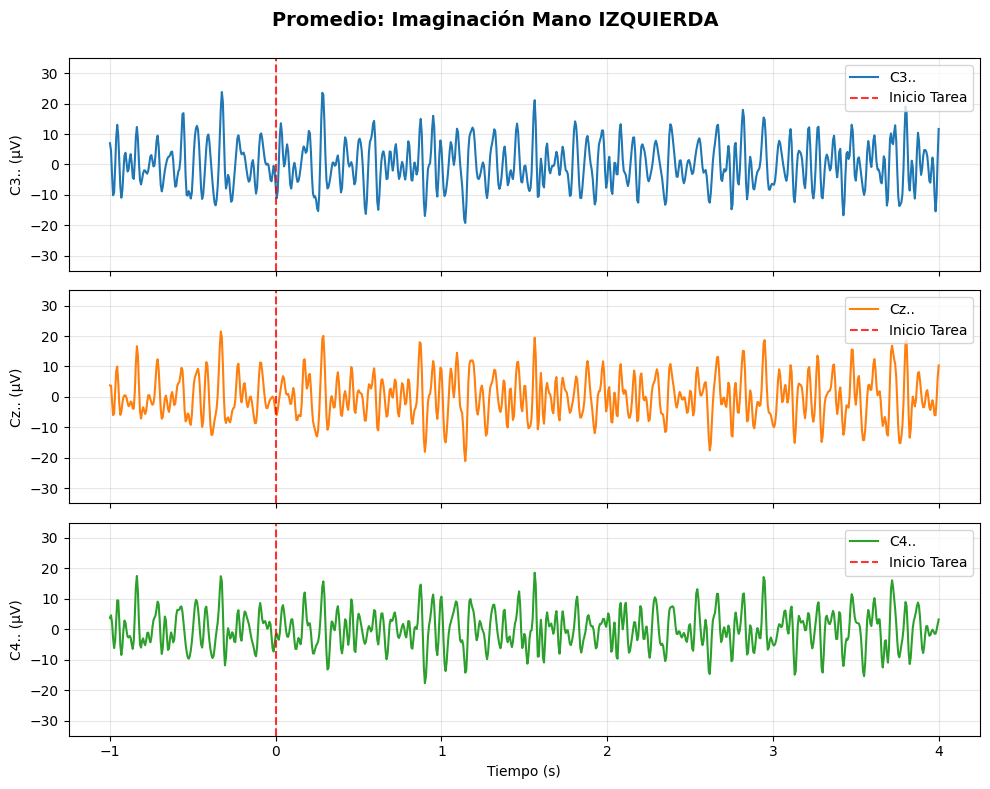

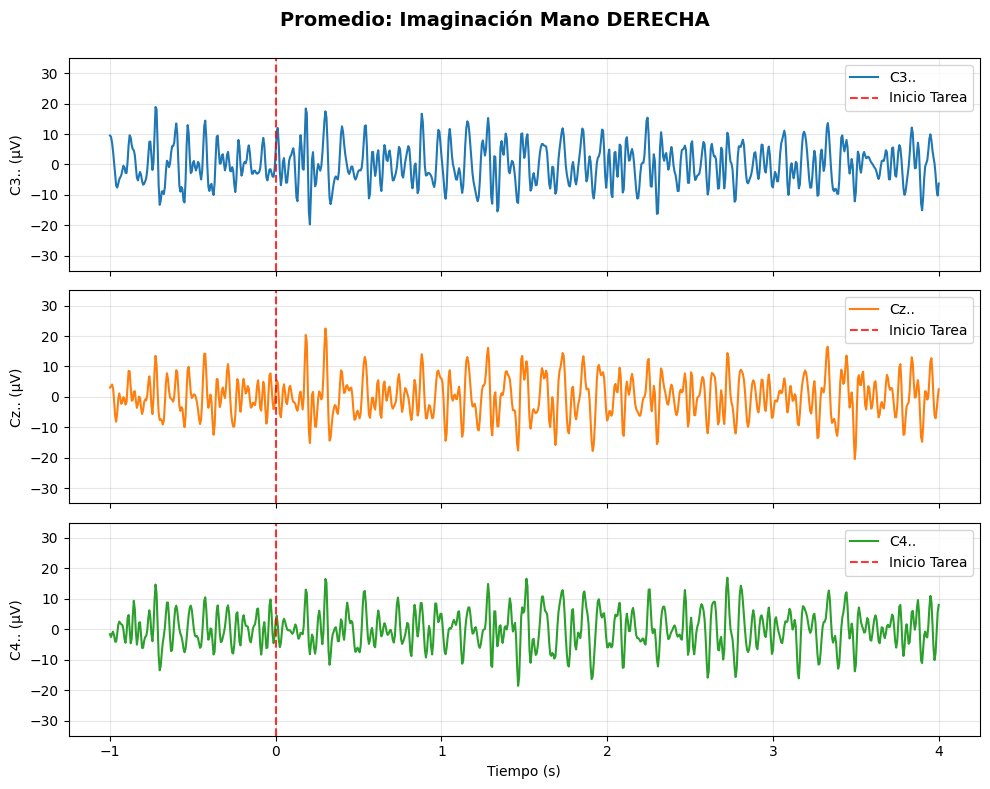

In [ ]:
#Validacipon visual de los promedios evocados (ERP) para cada tarea
import matplotlib.pyplot as plt

def graficar_evocado_claro(evocado, titulo):
    # Creamos una figura con 3 filas (una para cada canal)
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(titulo, fontsize=14, fontweight='bold')
    
    canales = evocado.ch_names # C3, Cz, C4
    tiempos = evocado.times
    datos = evocado.data * 1e6 # Pasamos a microvoltios
    
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
    
    for i in range(len(canales)):
        axs[i].plot(tiempos, datos[i], color=colores[i], label=canales[i])
        
        # DIBUJAMOS LA LÍNEA ROJA EN EL SEGUNDO 0
        axs[i].axvline(x=0, color='red', linestyle='--', alpha=0.8, label='Inicio Tarea')
        
        axs[i].set_ylabel(f"{canales[i]} (μV)")
        axs[i].grid(True, alpha=0.3)
        axs[i].legend(loc='upper right')
        
        # Ajustamos el límite vertical para que los picos de 30uV se vean bien
        axs[i].set_ylim([-35, 35]) 

    axs[-1].set_xlabel("Tiempo (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Ejecutamos para ambas tareas
graficar_evocado_claro(evocado_izq, "Promedio: Imaginación Mano IZQUIERDA")
graficar_evocado_claro(evocado_der, "Promedio: Imaginación Mano DERECHA")

## **welch**

In [59]:

# PSD - WELCH

print("Calculando la Densidad Espectral de Potencia (PSD) mediante Welch...")

# 1. Calculamos el espectro de potencia
# fmin y fmax definen tu rango de interés (8-30 Hz)
# n_fft=256 y n_overlap=128 cumplen con el 50% de solapamiento
psd_obj = epochs.compute_psd(method='welch', fmin=8, fmax=30, 
                             n_fft=256, n_overlap=128, verbose=False)

# 2. Extraemos los datos numéricos y las frecuencias
# psds tiene forma: (n_épocas, n_canales, n_frecuencias)
psds, freqs = psd_obj.get_data(return_freqs=True)

# 3. Convertimos a dB (decibelios) para que la escala sea más fácil de leer
# Esto es opcional pero muy común en tesis para ver mejor las diferencias
psds_db = 10 * np.log10(psds)

print(f"-> Características extraídas con éxito.")
print(f"Forma de la matriz de potencia: {psds.shape}")

Calculando la Densidad Espectral de Potencia (PSD) mediante Welch...
-> Características extraídas con éxito.
Forma de la matriz de potencia: (29, 3, 36)


Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


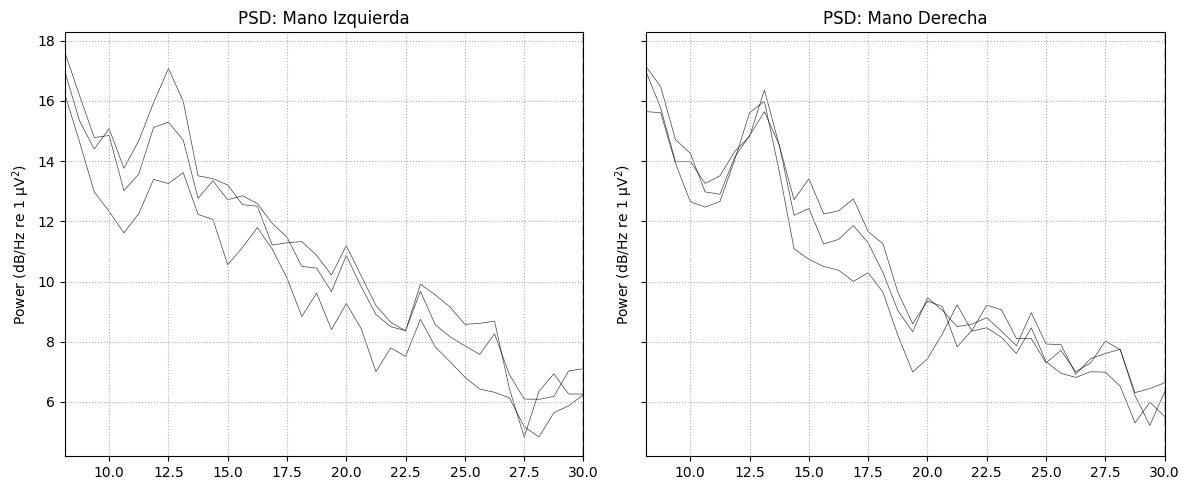

In [79]:

import matplotlib.pyplot as plt

# Calculamos el PSD promedio por condición para visualizar
psd_izq = epochs['Mano_Izquierda'].compute_psd(method='welch', fmin=8, fmax=30, n_fft=256, n_overlap=128)
psd_der = epochs['Mano_Derecha'].compute_psd(method='welch', fmin=8, fmax=30, n_fft=256, n_overlap=128)

# Graficamos
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

psd_izq.plot(picks='eeg', axes=ax[0], show=False)
ax[0].set_title('PSD: Mano Izquierda')

psd_der.plot(picks='eeg', axes=ax[1], show=False)
ax[1].set_title('PSD: Mano Derecha')

plt.tight_layout()
plt.show()

In [83]:
import pandas as pd
import numpy as np
from IPython.display import display

print("Construyendo el DataFrame vectorizado (C3, Cz, C4)...")

# Encontrar índices de los canales
nombre_c3 = [ch for ch in psd_izq.ch_names if 'C3' in ch][0]
nombre_cz = [ch for ch in psd_izq.ch_names if 'Cz' in ch][0]
nombre_c4 = [ch for ch in psd_izq.ch_names if 'C4' in ch][0]

idx_c3 = psd_izq.ch_names.index(nombre_c3)
idx_cz = psd_izq.ch_names.index(nombre_cz)
idx_c4 = psd_izq.ch_names.index(nombre_c4)

# Crear máscaras lógicas (booleanas) para las bandas de interés
freqs = psd_izq.freqs
mask_mu = (freqs >= 8) & (freqs <= 13)
mask_beta = (freqs >= 13) & (freqs <= 30)

# Extraer las matrices numéricas 3D (épocas, canales, frecuencias)
data_izq = psd_izq.get_data()
data_der = psd_der.get_data()

#Función vectorizada usando el parámetro "axis=1" de numpy
def crear_df_vectorizado(data, tarea, sujeto='Sujeto_01'):
    return pd.DataFrame({
        'Registro': sujeto,
        'Tarea': tarea,
        # np.mean promedia todas las frecuencias de la banda (axis=1) para TODAS las épocas a la vez
        'Potencia_Mu_C3': np.mean(data[:, idx_c3, mask_mu], axis=1),
        'Potencia_Mu_Cz': np.mean(data[:, idx_cz, mask_mu], axis=1),
        'Potencia_Mu_C4': np.mean(data[:, idx_c4, mask_mu], axis=1),
        
        'Potencia_Beta_C3': np.mean(data[:, idx_c3, mask_beta], axis=1),
        'Potencia_Beta_Cz': np.mean(data[:, idx_cz, mask_beta], axis=1),
        'Potencia_Beta_C4': np.mean(data[:, idx_c4, mask_beta], axis=1)
    })

#  Generar DataFrames y unirlos
df_izq = crear_df_vectorizado(data_izq, 'Mano_Izquierda')
df_der = crear_df_vectorizado(data_der, 'Mano_Derecha')

# Para que se pueda visualizar datos de mano izquierda y derecha en un mismo DataFrame- 
df_caracteristicas = pd.concat([df_izq, df_der], ignore_index=True)

print("DataFrame creado exitosamente")

# ---> COMPLEMENTO: Mostrar principio (Izquierda) y final (Derecha) <---
resumen_df = pd.concat([df_caracteristicas.head(2), df_caracteristicas.tail(2)])
display(resumen_df)

Construyendo el DataFrame vectorizado (C3, Cz, C4)...
DataFrame creado exitosamente


,Registro,Tarea,Potencia_Mu_C3,Potencia_Mu_Cz,Potencia_Mu_C4,Potencia_Beta_C3,Potencia_Beta_Cz,Potencia_Beta_C4
0,Sujeto_01,Mano_Izquierda,3.874538e-11,4.068721e-11,3.018466e-11,1.019800e-11,9.689842e-12,7.954852e-12
1,Sujeto_01,Mano_Izquierda,3.148630e-11,2.446677e-11,1.498459e-11,8.544518e-12,7.952399e-12,6.202563e-12
13,Sujeto_01,Mano_Derecha,3.981858e-11,3.653256e-11,2.058585e-11,9.797423e-12,8.584509e-12,7.145051e-12
14,Sujeto_01,Mano_Derecha,2.394337e-11,2.205973e-11,2.901011e-11,1.157385e-11,1.065262e-11,1.067056e-11


### Análisis Estadístico
**Hipótesis Nula ($H_0$):** No existe una diferencia estadísticamente significativa en la potencia de la banda Mu en los canales motores (C3, C4) al comparar la imaginación de la mano izquierda frente a la mano derecha.


**Hipótesis Alternativa ($H_1$):** Existe una diferencia estadísticamente significativa en la potencia de la banda Mu en los canales motores debido al fenómeno de Desincronización Relacionada con el Evento (ERD).

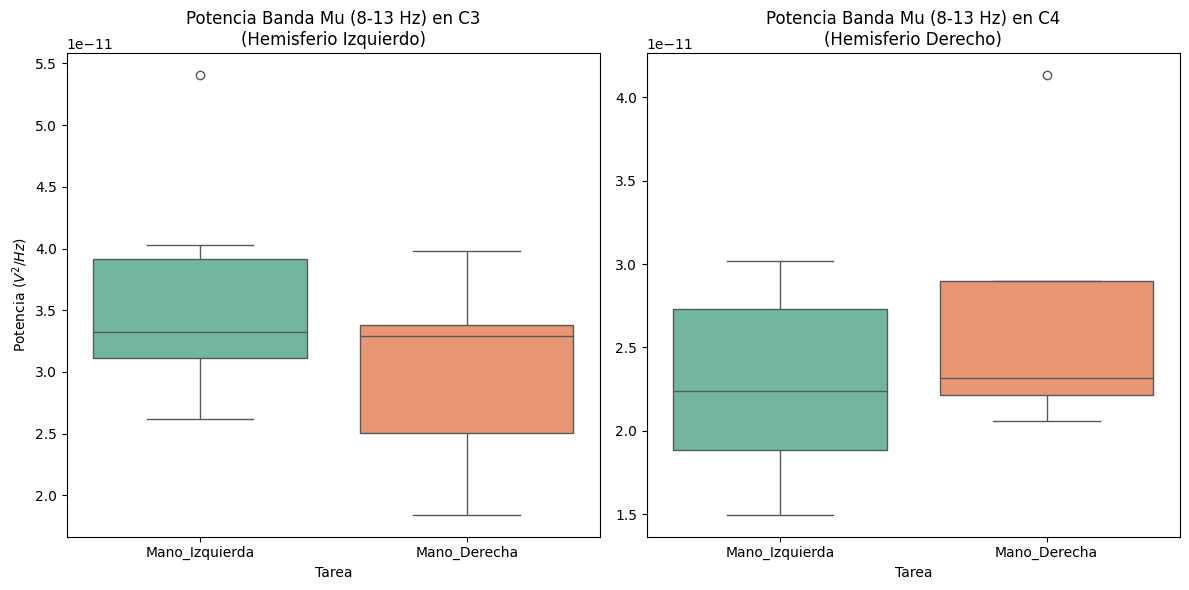

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ESTADÍSTICA DESCRIPTIVA (Gráficas Boxplot)
plt.figure(figsize=(12, 6))

# Boxplot para C3
plt.subplot(1, 2, 1)
sns.boxplot(x='Tarea', y='Potencia_Mu_C3', data=df_caracteristicas, palette='Set2')
plt.title('Potencia Banda Mu (8-13 Hz) en C3\n(Hemisferio Izquierdo)')
plt.ylabel('Potencia ($V^2/Hz$)')

# Boxplot para C4
plt.subplot(1, 2, 2)
sns.boxplot(x='Tarea', y='Potencia_Mu_C4', data=df_caracteristicas, palette='Set2')
plt.title('Potencia Banda Mu (8-13 Hz) en C4\n(Hemisferio Derecho)')
plt.ylabel('')

plt.tight_layout()
plt.show()



In [85]:
# PRUEBA DE NORMALIDAD (Shapiro-Wilk)
print("-" * 50)
print("PRUEBA DE NORMALIDAD (SHAPIRO-WILK) PARA CANAL C4")
print("-" * 50)

# Extraemos los datos numéricos para evaluarlos
datos_izq = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C4']
datos_der = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C4']

# Test de Shapiro-Wilk
stat_izq, p_izq = stats.shapiro(datos_izq)
stat_der, p_der = stats.shapiro(datos_der)

print(f"P-valor (Mano Izquierda): {p_izq:.5f}")
print(f"P-valor (Mano Derecha): {p_der:.5f}\n")

if p_izq > 0.05 and p_der > 0.05:
    print("CONCLUSIÓN: Los datos son NORMALES (p > 0.05).")
    print("Siguiente paso -> Aplicar T-Student (Paramétrica)")
else:
    print("CONCLUSIÓN: Los datos NO SON NORMALES (p <= 0.05).")
    print("Siguiente paso -> Aplicar U de Mann-Whitney (No Paramétrica)")

--------------------------------------------------
PRUEBA DE NORMALIDAD (SHAPIRO-WILK) PARA CANAL C4
--------------------------------------------------
P-valor (Mano Izquierda): 0.53450
P-valor (Mano Derecha): 0.05811

CONCLUSIÓN: Los datos son NORMALES (p > 0.05).
Siguiente paso -> Aplicar T-Student (Paramétrica)


In [86]:
from scipy import stats

# PRUEBA ESTADÍSTICA (T-STUDENT)

print("--- PRUEBA T DE STUDENT (Mano Izq vs Mano Der) ---\n")

# Extraemos los datos de la banda Mu para C3 y C4
mu_izq_C3 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C3']
mu_der_C3 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C3']

mu_izq_C4 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C4']
mu_der_C4 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C4']

# Aplicamos la prueba T de Student (muestras independientes) para C3
t_stat_c3, p_val_c3 = stats.ttest_ind(mu_izq_C3, mu_der_C3)

# Aplicamos la prueba T de Student para C4
t_stat_c4, p_val_c4 = stats.ttest_ind(mu_izq_C4, mu_der_C4)

#  Mostrar e interpretar resultados
print("Resultados en Canal C3 (Corteza Motora Izquierda):")
print(f"Estadístico T: {t_stat_c3:.4f} | P-valor: {p_val_c3:.5f}")
if p_val_c3 < 0.05:
    print("-> CONCLUSIÓN: Hay diferencia significativa en C3 (Se rechaza la Hipótesis Nula H0)\n")
else:
    print("-> CONCLUSIÓN: NO hay diferencia significativa en C3 (No se rechaza H0)\n")

print("Resultados en Canal C4 (Corteza Motora Derecha):")
print(f"Estadístico T: {t_stat_c4:.4f} | P-valor: {p_val_c4:.5f}")
if p_val_c4 < 0.05:
    print("-> CONCLUSIÓN: Hay diferencia significativa en C4 (Se rechaza la Hipótesis Nula H0)\n")
else:
    print("-> CONCLUSIÓN: NO hay diferencia significativa en C4 (No se rechaza H0)\n")

--- PRUEBA T DE STUDENT (Mano Izq vs Mano Der) ---

Resultados en Canal C3 (Corteza Motora Izquierda):
Estadístico T: 1.4611 | P-valor: 0.16774
-> CONCLUSIÓN: NO hay diferencia significativa en C3 (No se rechaza H0)

Resultados en Canal C4 (Corteza Motora Derecha):
Estadístico T: -1.1718 | P-valor: 0.26229
-> CONCLUSIÓN: NO hay diferencia significativa en C4 (No se rechaza H0)



## Referencias

[1]	A. Arjoonsingh, B. C. Jamal, and L. Ganti, “History and evolution of the electroencephalogram,” Cureus, vol. 16, no. 8, p. e66385, 2024. DOI: 10.7759/cureus.66385

[2] [Aplicaciones Reales de Interfaces Cerebro-Computadora](https://www.emotiv.com/es/blogs/news/brain-computer-interface-applications?srsltid=AfmBOoojTE66RzGV6x_orurA8rRNHyRrN4pjjo8hAX3lC5JDrejhn94o)

[3] [Brain-Computer Interfaces in Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3497935/)

[4] [The Berlin Brain–Computer Interface: Non-Medical Uses of BCI Technology](https://pmc.ncbi.nlm.nih.gov/articles/PMC3002462/)

[5] [EEG-based brain-computer interface enables real-time robotic hand control at individual finger level](https://www.nature.com/articles/s41467-025-61064-x)

Papers que nos pueden servir para el desarrollo del flujo y selección de las bandas 

- [An Empirical Model-Based Algorithm for Removing Motion-Caused Artifacts in Motor Imagery EEG Data for Classification Using an Optimized CNN Model](https://pubmed.ncbi.nlm.nih.gov/39686227/)
- [Cortical signals analysis to recognize intralimb mobility using modified RNN and various EEG quantities](https://pubmed.ncbi.nlm.nih.gov/38726180/)
- [Direction decoding of imagined hand movements using subject-specific features from parietal EEG](https://pubmed.ncbi.nlm.nih.gov/35901779/)
- [Decoding trajectories of imagined hand movement using electrocorticograms for brain-machine interface](https://pubmed.ncbi.nlm.nih.gov/35985293/)
- [Induced Gamma-Band Activity during Actual and Imaginary Movements: EEG Analysis](https://pubmed.ncbi.nlm.nih.gov/32168747/) Bandas de interés
- [Classifying EEG signals preceding right hand, left hand, tongue, and right foot movements and motor imageries](https://pubmed.ncbi.nlm.nih.gov/18845473/) De 2008
- [Mu-Beta event-related (de)synchronization and EEG classification of left-right foot dorsiflexion kinaesthetic motor imagery for BCI](https://pubmed.ncbi.nlm.nih.gov/32182270/)
- [Effect of brain-computer interface training based on non-invasive electroencephalography using motor imagery on functional recovery after stroke - a systematic review and meta-analysis](https://pubmed.ncbi.nlm.nih.gov/33092554/)
- [A Comprehensive Review on Critical Issues and Possible Solutions of Motor Imagery Based Electroencephalography Brain-Computer Interface](https://pubmed.ncbi.nlm.nih.gov/33804611/)
- [Classification of EEG signals recorded during right/left hand movement imagery using Fast Walsh Hadamard Transform based features](https://ieeexplore-ieee-org.udea.lookproxy.com/document/7760909) ¿Fast Walsh Hadamard Transform?

consulta -> resumen del proyecto en general


#### Filtros lineales 
La salida no se desfasa con respecto a  la entrada
- Filtros en frecuencia o en amplitud.

FIR e IIR son en recuencia.


### Filtros no lineales

Wavelet es en amplitud, lo descompone en aproximaciones y detalles 


Orden y frecuancia de corte son los parámetros más importates del filtro


RAW -> detrend -> Pasabanda -> FILTERED -> FFT welch -> PSD en las bandas de interés. Sumar la desidad de potencia espectral y se divide por la totalidad, eso me da la **potencia relativa** -> ahí se tiene en cuenta la tarea 

Buacar en la literatura el solapamiento de welch